# Analyse du Data Drift — Home Credit MLOps

Compare les features envoyées en production (table `production_inputs`,
alimentée par l'API `/predict`) aux données d'entraînement du modèle
champion (`data/processed/train_features.parquet`), pour détecter une
dérive de distribution.

Réutilise directement `src/home_credit_mlops/monitoring/drift.py` — la
même logique PSI/KS que celle utilisée par le dashboard Streamlit et le
rapport automatique (`scripts/analyze_production_monitoring.py`). Ce
notebook ne duplique pas la logique métier, il l'appelle et en interprète
les résultats.

**Prérequis** : `PREDICTION_DB_URL` doit pointer vers une base PostgreSQL
contenant de vraies données de production (locale ou Neon).

## 1. Configuration

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from home_credit_mlops.data.io import read_table
from home_credit_mlops.monitoring.drift import (
    DriftConfig,
    compute_categorical_drift,
    compute_numeric_drift,
    summarize_drift,
)
from home_credit_mlops.monitoring.production import load_production_inputs
from home_credit_mlops.settings import load_settings

%matplotlib inline
pd.set_option("display.max_columns", 30)

In [2]:
settings = load_settings()

database_url = os.environ.get("PREDICTION_DB_URL")
if not database_url:
    raise RuntimeError(
        "PREDICTION_DB_URL n'est pas defini. Exporter la chaine de connexion "
        "PostgreSQL (locale via docker-compose, ou Neon pour la base de "
        "production reelle deployee sur Render) avant de lancer ce notebook."
    )

reference_data_path = settings.dataset.default_train_path
target_column = settings.dataset.target_column
id_column = settings.dataset.id_column

print("Reference dataset :", reference_data_path)
print("Colonne cible / id :", target_column, "/", id_column)

Reference dataset : /home/maxime/projects/home-credit-mlops/data/processed/train_features.parquet
Colonne cible / id : TARGET / SK_ID_CURR


## 2. Chargement des données

- **Référence** : le jeu d'entraînement complet (`train_features.parquet`),
  moins les colonnes `TARGET`/`SK_ID_CURR` qui ne font pas partie du
  contrat de l'API.
- **Production** : les features réellement envoyées à `/predict` et
  journalisées dans `production_inputs` (une ligne par prédiction réussie).

Seules les colonnes communes aux deux jeux sont comparées.

In [3]:
reference_raw = read_table(reference_data_path)
reference_features = reference_raw.drop(
    columns=[c for c in (target_column, id_column) if c in reference_raw.columns]
)

production_features = load_production_inputs(database_url)

print(f"Reference : {reference_features.shape[0]:,} lignes, {reference_features.shape[1]} colonnes")
print(f"Production : {production_features.shape[0]:,} lignes, {production_features.shape[1]} colonnes")

shared_features = [c for c in reference_features.columns if c in production_features.columns]
print(f"Colonnes partagees : {len(shared_features)}")

reference_aligned = reference_features[shared_features]
production_aligned = production_features[shared_features]

Reference : 307,511 lignes, 548 colonnes
Production : 100 lignes, 552 colonnes
Colonnes partagees : 548


## 3. Calcul de la dérive (PSI + KS)

- **PSI** (Population Stability Index) : mesure le déplacement de
  distribution, numérique comme catégoriel. Seuils : `< 0.10` faible,
  `0.10–0.25` modéré, `≥ 0.25` élevé.
- **KS** (test de Kolmogorov-Smirnov) : complète le PSI pour les variables
  numériques. Seuils : `< 0.10` faible, `0.10–0.20` modéré, `≥ 0.20` élevé.
- **Variation du taux de valeurs manquantes** : un delta `≥ 0.10` est
  considéré comme une dérive à lui seul (un changement de complétude des
  données est un signal important, indépendamment de la distribution des
  valeurs présentes).
- En dessous de **30 lignes** de production, le niveau est marqué
  `insufficient_data` plutôt que sur-interprété.

In [4]:
drift_config = DriftConfig()

numeric_drift = compute_numeric_drift(reference_aligned, production_aligned, config=drift_config)
categorical_drift = compute_categorical_drift(reference_aligned, production_aligned, config=drift_config)

drift_summary = summarize_drift(numeric_drift, categorical_drift)
drift_summary

,feature_count,high_drift_count,moderate_drift_count,insufficient_data_count,max_psi,mean_psi
0,528,71,160,0,4.724761,0.150873


In [5]:
all_drift = pd.concat([numeric_drift, categorical_drift], ignore_index=True)
all_drift.sort_values("psi", ascending=False).head(20)

,feature,feature_type,reference_missing_rate,current_missing_rate,missing_rate_delta,reference_mean,current_mean,mean_delta,psi,ks_statistic,ks_pvalue,current_rows,drift_level,reference_unique_count,current_unique_count
512,OCCUPATION_TYPE,categorical,0.313455,0.00,-0.313455,NaN,NaN,NaN,4.724761,NaN,NaN,100,high,18.0,12.0
0,BURO_BB_MONTHS_BALANCE_SIZE_SUM,numeric,0.143149,0.17,0.026851,55.795498,232.048193,176.252695,2.758868,0.678643,2.108253e-38,100,high,NaN,NaN
1,CC_CNT_DRAWINGS_ATM_CURRENT_MAX,numeric,0.801178,0.78,-0.021178,3.995895,3.590909,-0.404986,2.668470,0.164600,5.363018e-01,100,high,NaN,NaN
2,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,numeric,0.801178,0.78,-0.021178,1.750056,0.914615,-0.835441,2.464893,0.121590,8.625785e-01,100,high,NaN,NaN
3,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,numeric,0.801178,0.78,-0.021178,0.566241,0.256942,-0.309299,2.446685,0.242736,1.259931e-01,100,high,NaN,NaN
4,AMT_REQ_CREDIT_BUREAU_MON,numeric,0.135016,0.17,0.034984,0.267395,0.000000,-0.267395,2.005474,0.164512,1.973824e-02,100,high,NaN,NaN
5,CREDIT_TO_ANNUITY_RATIO,numeric,0.000039,0.00,-0.000039,21.612322,16.875572,-4.736750,1.676631,0.289446,6.504906e-08,100,high,NaN,NaN
6,COMMONAREA_MODE,numeric,0.698723,0.65,-0.048723,0.042553,0.055666,0.013113,1.344191,0.158387,3.100723e-01,100,high,NaN,NaN
7,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,numeric,0.801178,0.78,-0.021178,12291.586142,7064.052047,-5227.534096,1.323758,0.199323,3.043750e-01,100,high,NaN,NaN
8,CC_AMT_PAYMENT_CURRENT_MEAN,numeric,0.801438,0.78,-0.021438,18028.676163,12385.524526,-5643.151637,1.307753,0.144662,6.938087e-01,100,high,NaN,NaN


## 4. Top variables en dérive

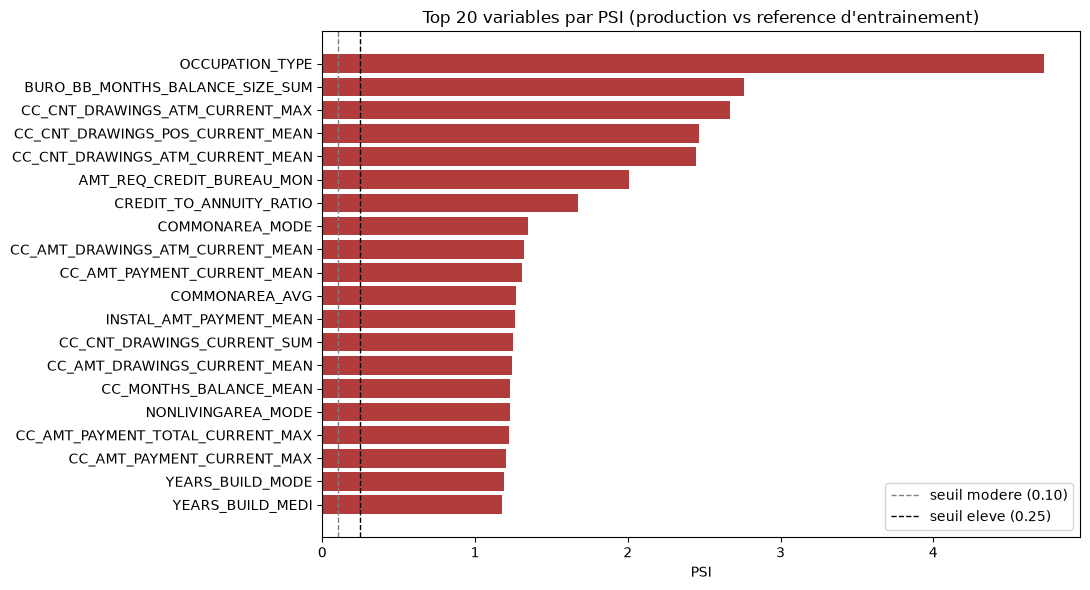

In [6]:
top_n = 20
top_drift = all_drift.sort_values("psi", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(11, 6))
colors = top_drift["drift_level"].map(
    {"high": "#B23B3B", "moderate": "#C98A2B", "low": "#2E7D4F", "insufficient_data": "#8892A0"}
)
ax.barh(top_drift["feature"][::-1], top_drift["psi"][::-1], color=colors[::-1])
ax.axvline(0.10, color="grey", linestyle="--", linewidth=1, label="seuil modere (0.10)")
ax.axvline(0.25, color="black", linestyle="--", linewidth=1, label="seuil eleve (0.25)")
ax.set_xlabel("PSI")
ax.set_title(f"Top {top_n} variables par PSI (production vs reference d'entrainement)")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
print("Repartition des niveaux de derive :")
print(all_drift["drift_level"].value_counts())

Repartition des niveaux de derive :
drift_level
low         297
moderate    160
high         71
Name: count, dtype: int64


## 5. Interprétation

Deux causes distinctes expliquent la majorité des variables en dérive
"élevée" sur ce jeu de données de production simulé, identifiées en
creusant le tableau ci-dessus plutôt qu'en s'arrêtant au chiffre brut :

1. **Colonnes requises par le schéma de l'API, mais optionnelles à
   l'entraînement** (ex. `OCCUPATION_TYPE`) : le modèle a été entraîné
   avec un vrai taux de valeurs manquantes sur ces colonnes (30 à 80 %
   selon la colonne), mais le schéma Pydantic généré depuis la signature
   MLflow les marque comme requises — l'API rejette une valeur nulle. Le
   `current_missing_rate` de ces colonnes tombe donc à 0 en production,
   quelle que soit la taille de l'échantillon. Ce n'est pas une dérive du
   modèle, c'est un écart entre le contrat d'API déployé et ce que
   l'entraînement autorisait — un point à surveiller pour un vrai
   déploiement (revoir le typage `Optional` de ces colonnes), pas un
   signal opérationnel à traiter en urgence.
2. **Instabilité statistique sur un petit échantillon** : sur les
   colonnes très creuses (ex. agrégats `CC_*`/`BURO_*`, 70 à 80 % de
   valeurs manquantes en référence), un échantillon de production de
   quelques dizaines à quelques centaines de lignes ne laisse qu'une
   poignée de valeurs non nulles à comparer — le PSI devient bruyant
   même quand `missing_rate_delta` reste proche de zéro. Ce signal
   redescend avec un plus grand volume de trafic réel.

**Recommandation** : ne pas interpréter un PSI élevé isolément — croiser
avec `missing_rate_delta` et `current_rows` avant de conclure à une
vraie dérive de distribution.

## 6. Conclusion

- Le mécanisme de détection (PSI + KS, seuils explicites, garde-fou
  `insufficient_data`) fonctionne et reflète fidèlement les données
  réellement stockées en production.
- La dérive mesurée sur l'échantillon actuel est en grande partie
  explicable (contrat de schéma, taille d'échantillon) plutôt qu'un
  signal de dérive réelle du modèle — mais le système la détecterait
  aussi bien si un vrai changement de population de clients survenait.
- Pour un suivi continu, `scripts/analyze_production_monitoring.py`
  génère automatiquement la même analyse (classeur Excel, rapport HTML,
  graphiques), et le dashboard Streamlit (`dashboard/monitoring_app.py`)
  l'expose en direct, sans avoir à relancer ce notebook manuellement.